In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [98]:
df= pd.read_csv("Retail_Cleaned.csv") 


In [99]:
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied,Month,Month_Num,Year,Day,Week
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True,April,4,2024,Monday,15
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True,July,7,2023,Sunday,29
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False,October,10,2022,Wednesday,40
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,0,May,5,2022,Saturday,18
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False,October,10,2022,Sunday,39


In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              12575 non-null  object 
 4   Price Per Unit    12575 non-null  float64
 5   Quantity          12575 non-null  float64
 6   Total Spent       12575 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  12575 non-null  object 
 11  Month             12575 non-null  object 
 12  Month_Num         12575 non-null  int64  
 13  Year              12575 non-null  int64  
 14  Day               12575 non-null  object 
 15  Week              12575 non-null  int64  
dtypes: float64(3), int64(3), object(10)
memo

In [101]:
df.isnull().sum()

Transaction ID      0
Customer ID         0
Category            0
Item                0
Price Per Unit      0
Quantity            0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
Discount Applied    0
Month               0
Month_Num           0
Year                0
Day                 0
Week                0
dtype: int64

In [102]:
#removing null values from column item
df['Item']=df['Item'].fillna(method='ffill')
df['Item']=df['Item'].fillna("unknown item")

C:\Users\sachi\AppData\Local\Temp\ipykernel_18588\2217434548.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Item']=df['Item'].fillna(method='ffill')


In [103]:
#removing null values from column price per unit
df['Price Per Unit']=df['Price Per Unit'].fillna(df['Price Per Unit'].median())

In [104]:
#removing null values from column Quantity
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median())


In [105]:
# it fill the null values by 0 in column Discounnt Applied
df['Discount Applied'] = df['Discount Applied'].fillna(0)


In [106]:
# it multiplies both columns to get total spent
df['Total Spent'] = df['Price Per Unit'] * df['Quantity']

In [107]:
df.isnull().sum()

Transaction ID      0
Customer ID         0
Category            0
Item                0
Price Per Unit      0
Quantity            0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
Discount Applied    0
Month               0
Month_Num           0
Year                0
Day                 0
Week                0
dtype: int64

In [108]:
# it corrects date format
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])


In [109]:
df.head(5)

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied,Month,Month_Num,Year,Day,Week
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True,April,4,2024,Monday,15
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True,July,7,2023,Sunday,29
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False,October,10,2022,Wednesday,40
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,0,May,5,2022,Saturday,18
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False,October,10,2022,Sunday,39


In [110]:
df['Quantity'] = pd.to_numeric(df['Quantity'])
df['Price Per Unit'] = pd.to_numeric(df['Price Per Unit'])
df['Total Spent'] = pd.to_numeric(df['Total Spent'])


In [111]:
df['Category'] = df['Category'].astype('category')
df['Payment Method'] = df['Payment Method'].astype('category')
df['Location'] = df['Location'].astype('category')


In [112]:
df['Month']=df['Transaction Date'].dt.month_name()

In [113]:
df['Month_Num']=df['Transaction Date'].dt.month

In [114]:
df['Year']=df['Transaction Date'].dt.year

In [115]:
df['Day']=df['Transaction Date'].dt.day_name()

In [116]:
df['Week'] = df['Transaction Date'].dt.isocalendar().week


In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    12575 non-null  object        
 1   Customer ID       12575 non-null  object        
 2   Category          12575 non-null  category      
 3   Item              12575 non-null  object        
 4   Price Per Unit    12575 non-null  float64       
 5   Quantity          12575 non-null  float64       
 6   Total Spent       12575 non-null  float64       
 7   Payment Method    12575 non-null  category      
 8   Location          12575 non-null  category      
 9   Transaction Date  12575 non-null  datetime64[ns]
 10  Discount Applied  12575 non-null  object        
 11  Month             12575 non-null  object        
 12  Month_Num         12575 non-null  int32         
 13  Year              12575 non-null  int32         
 14  Day               1257

In [118]:
df['Total Spent'].sum()


np.float64(1636195.5)

In [119]:
df.shape[0]

12575

In [120]:
df['Customer ID'].nunique()

25

In [121]:
df.groupby('Category')['Total Spent'].sum().sort_values(ascending=False).head()


C:\Users\sachi\AppData\Local\Temp\ipykernel_18588\1043975069.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Category')['Total Spent'].sum().sort_values(ascending=False).head()


Category
Butchers                         217397.0
Electric household essentials    213401.5
Beverages                        206617.5
Food                             205684.0
Furniture                        205324.0
Name: Total Spent, dtype: float64

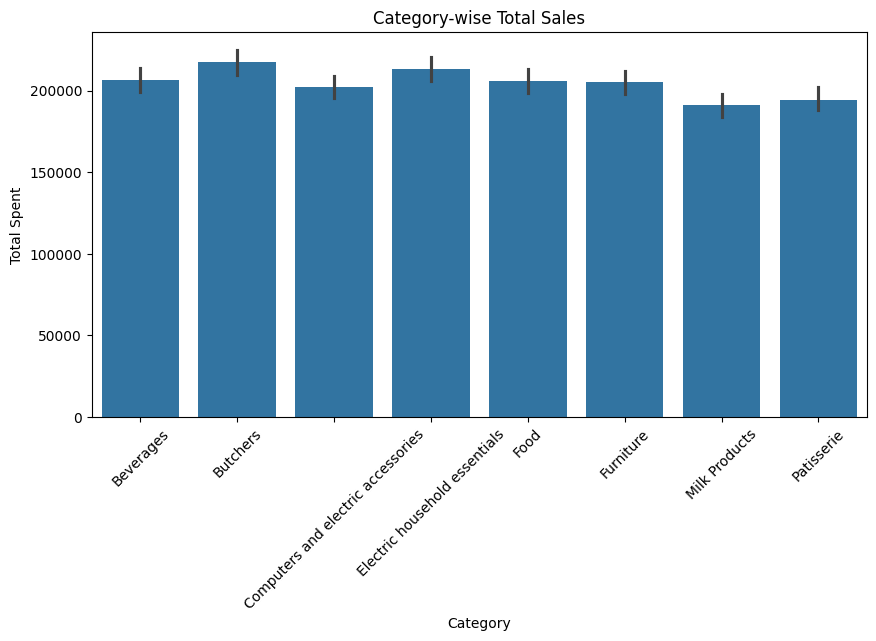

In [122]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.barplot(x='Category', y='Total Spent', data=df, estimator=sum)
plt.title("Category-wise Total Sales")
plt.xticks(rotation=45)
plt.show()


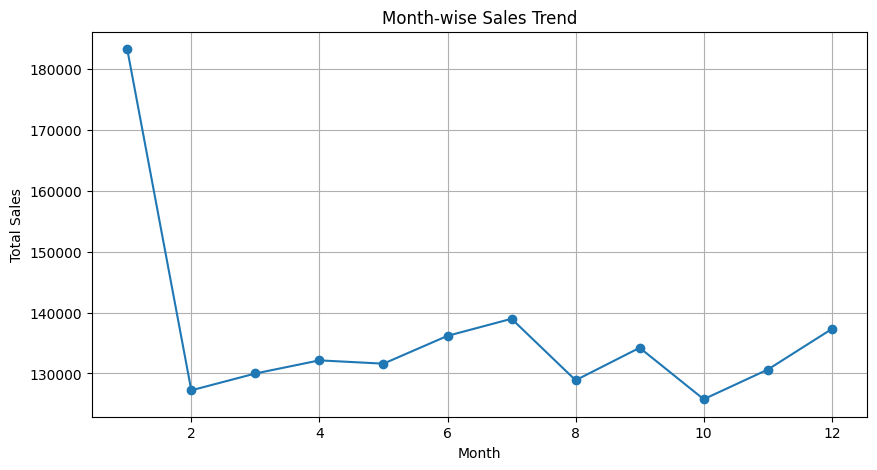

In [123]:
# Month-wise total sales
monthly = df.groupby('Month_Num')['Total Spent'].sum()

plt.figure(figsize=(10,5))
plt.plot(monthly.index, monthly.values, marker='o')
plt.title("Month-wise Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()


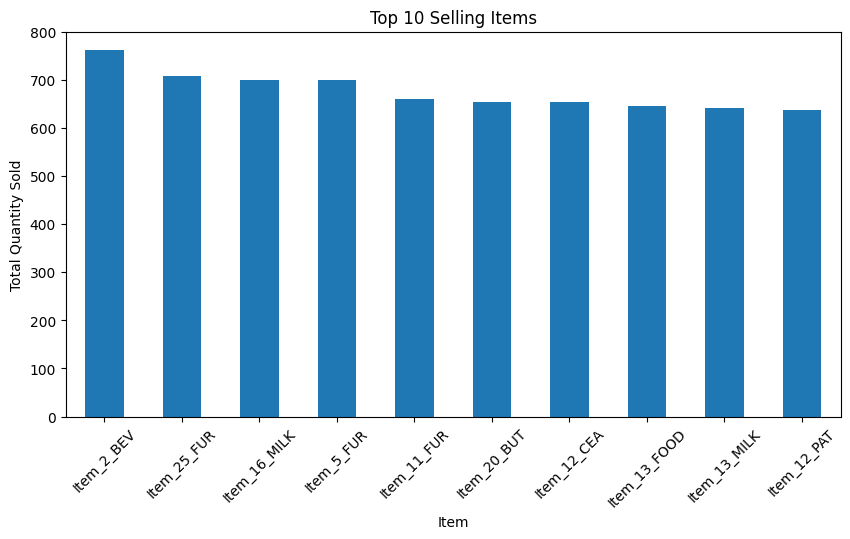

In [124]:
top_items = df.groupby('Item')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_items.plot(kind='bar')
plt.title("Top 10 Selling Items")
plt.ylabel("Total Quantity Sold")
plt.xlabel("Item")
plt.xticks(rotation=45)
plt.show()


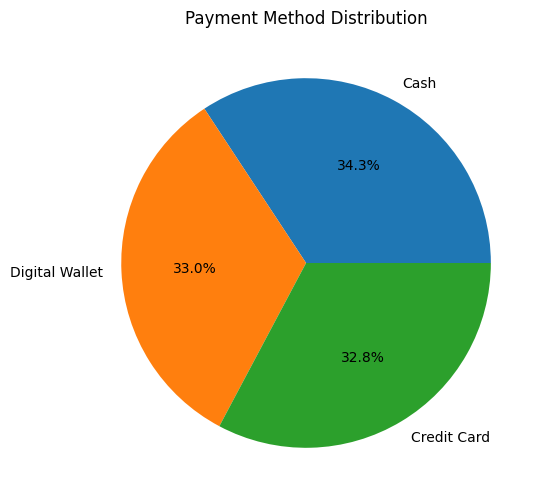

In [125]:
df['Payment Method'].value_counts().plot(
    kind='pie', 
    autopct='%1.1f%%', 
    figsize=(6,6)
)

plt.title("Payment Method Distribution")
plt.ylabel("")
plt.show()


C:\Users\sachi\AppData\Local\Temp\ipykernel_18588\152631688.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  location_sales = df.groupby('Location')['Total Spent'].sum().sort_values(ascending=False)


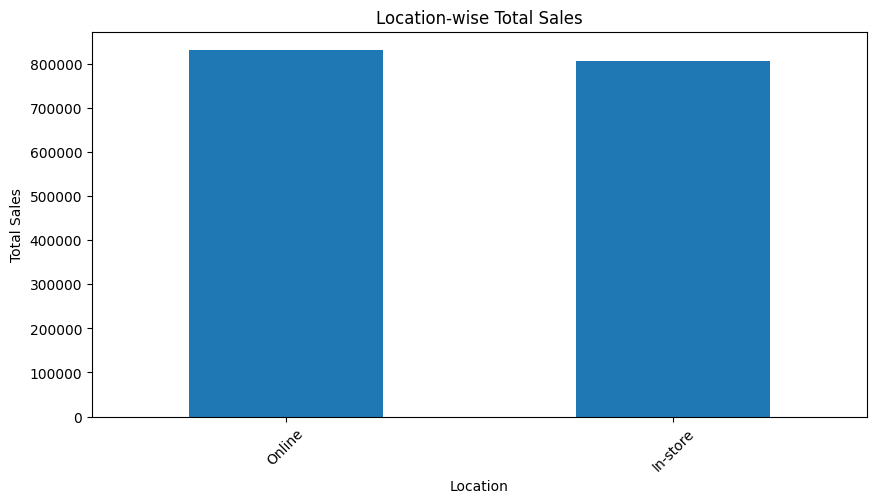

In [126]:
location_sales = df.groupby('Location')['Total Spent'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
location_sales.plot(kind='bar')
plt.title("Location-wise Total Sales")
plt.xlabel("Location")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()


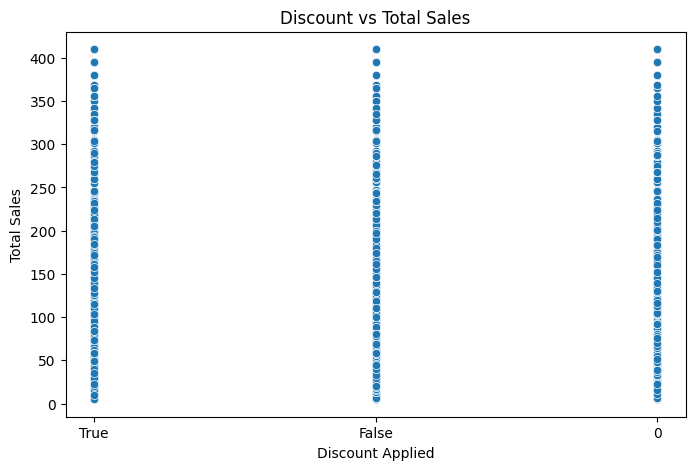

In [127]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.scatterplot(x='Discount Applied', y='Total Spent', data=df)
plt.title("Discount vs Total Sales")
plt.xlabel("Discount Applied")
plt.ylabel("Total Sales")
plt.show()


In [128]:
df.to_csv("Retail_Cleaned.csv", index=False)
